In [1]:
import importlib
import Multiclass_functions_1

import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from Multiclass_functions_1 import * # import all functions
DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [2]:
importlib.reload(Multiclass_functions_1)
from Multiclass_functions_1 import * 

In [ ]:
BATCH_SIZE = 32
LR = 1e-3
LR_STEP = 3
LR_GAMMA = 0.9
EPOCH = 20
TRAIN_RATIO = 0.8
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "CNN_deep"
dataset = "STL10"
save_model_path = f'/Volumes/김상현/results/MC_STL10/{model_type}_{dataset}.pt'

In [7]:
transform_train = transforms.ToTensor()
transform_test = transforms.ToTensor()

In [8]:

train_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "train", download = False, transform = transform_train)

# train data에 일부를 val data set으로 설정하는 작업
NoT = int(len(train_DS) * TRAIN_RATIO)
NoV = len(train_DS) - NoT
train_DS, val_DS = torch.utils.data.random_split(train_DS, [NoT, NoV])
val_DS.transform = transform_test
test_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "test", download = False, transform = transform_test)

# Batch_size에 맞게 데이터 load
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [12]:
print("Information of train dataset")
print(train_DS)
print("Information of test dataset")
print(test_DS)
print(f"Size of train dataset {len(train_DS)}")
print(f"Size of test dataset {len(test_DS)}")

Information of train dataset
Dataset STL10
    Number of datapoints: 5000
    Root location: /Volumes/김상현/dataset
    Split: train
    StandardTransform
Transform: ToTensor()
Information of test dataset
Dataset STL10
    Number of datapoints: 8000
    Root location: /Volumes/김상현/dataset
    Split: test
    StandardTransform
Transform: ToTensor()
Size of train dataset 5000
Size of test dataset 8000


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
torch.Size([32, 3, 96, 96])
bird


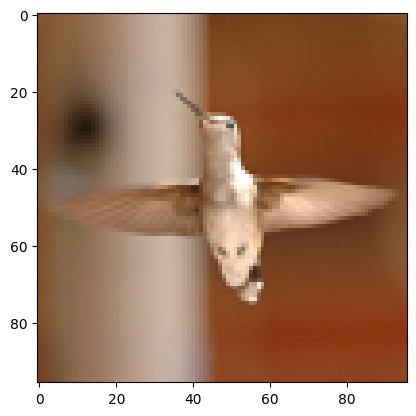

In [15]:
print(test_DS.classes)
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

In [9]:
class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        
        # self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
        #                                 nn.Linear(512,10))
        self.classifier = nn.Sequential(nn.Linear(128*12*12,512),
                                        nn.Linear(512,10))    
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        # x = torch.flatten(x, start_dim=1) # !!!!!!!
        # x = self.classifier(x)
        x = torch.flatten(x, start_dim=1) # !!!!!!!
        x = self.classifier(x)
        return x

In [10]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

In [12]:
def Train(model, train_DL, val_DL, criteron, optimizer, EPOCH):
    loss_history = []
    acc_history = []
    val_loss_history = []
    val_acc_history = []
    NoT = len(train_DL.dataset)
    NoV = len(val_DL.dataset)

    for ep in range(EPOCH):
        # model을 훈련모드로 전환 --> dropout, BatchNorm 등 훈련과 test에서 작용 방식이 다른 놈들을 위한
        model.train()
        rloss = 0
        rcorrect = 0
        for x_batch, y_batch in train_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # loss
            loss = criteron(y_hat, y_batch)
            # update
            optimizer.zero_grad() # 각 epoch마다 gradient 누적방지
            # backprop
            loss.backward()
            # weight update
            optimizer.step()
            # loss accum
            loss_b = loss.item() * x_batch.shape[0]
            rloss += loss_b
            # accuracy accum
            pred = y_hat.argmax(dim = 1)
            correct_b = torch.sum(pred == y_batch).item()
            rcorrect += correct_b

        loss_e = rloss / NoT
        loss_history += [loss_e]
        accuracy_e = rcorrect / NoT * 100
        acc_history += [accuracy_e]

        # Vali
        model.eval()
        val_rloss = 0
        val_rcorrect = 0
        with torch.no_grad():
            for x_batch, y_batch in val_DL:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                # inference
                y_hat = model(x_batch)
                # loss
                val_loss = criteron(y_hat, y_batch)
                # loss accum
                val_loss_b = val_loss.item() * x_batch.shape[0]
                val_rloss += val_loss_b
                # accuracy accum
                pred = y_hat.argmax(dim = 1)
                correct_b = torch.sum(pred == y_batch).item()
                val_rcorrect += correct_b

        val_loss_e = val_rloss / NoV
        val_loss_history += [val_loss_e]
        val_accuracy_e = val_rcorrect / NoV * 100
        val_acc_history += [val_accuracy_e]

        print(f"Epoch: {ep+1}, train loss: {round(loss_e, 3)}, val loss: {round(val_loss_e, 3)}")
        print(f"Train Accuracy: {rcorrect}/{NoT} ({round(accuracy_e, 1)}%)")
        print(f"Val Accuracy: {val_rcorrect}/{NoV} ({round(val_accuracy_e, 1)}%)")
        print("-"*20)

    return loss_history, acc_history, val_loss_history, val_acc_history

Epoch: 1, train loss: 7.798, val loss: 2.716
Train Accuracy: 615/4000 (15.4%)
Val Accuracy: 236/1000 (23.6%)
--------------------
Epoch: 2, train loss: 2.138, val loss: 1.854
Train Accuracy: 1109/4000 (27.7%)
Val Accuracy: 373/1000 (37.3%)
--------------------
Epoch: 3, train loss: 1.776, val loss: 1.642
Train Accuracy: 1418/4000 (35.4%)
Val Accuracy: 405/1000 (40.5%)
--------------------
Epoch: 4, train loss: 1.584, val loss: 1.536
Train Accuracy: 1649/4000 (41.2%)
Val Accuracy: 422/1000 (42.2%)
--------------------
Epoch: 5, train loss: 1.515, val loss: 1.437
Train Accuracy: 1772/4000 (44.3%)
Val Accuracy: 475/1000 (47.5%)
--------------------
Epoch: 6, train loss: 1.407, val loss: 1.377
Train Accuracy: 1926/4000 (48.1%)
Val Accuracy: 497/1000 (49.7%)
--------------------
Epoch: 7, train loss: 1.327, val loss: 1.301
Train Accuracy: 2014/4000 (50.3%)
Val Accuracy: 533/1000 (53.3%)
--------------------
Epoch: 8, train loss: 1.247, val loss: 1.282
Train Accuracy: 2163/4000 (54.1%)
Val A

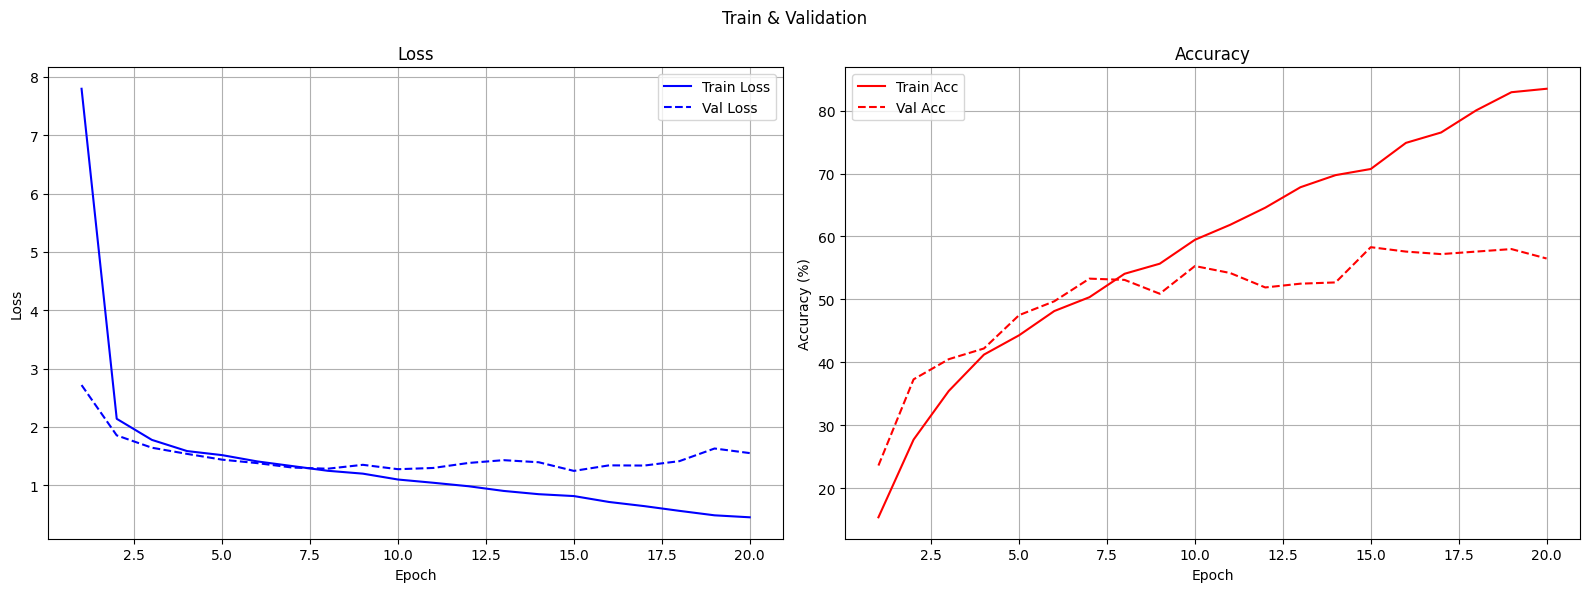

In [13]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history, val_loss_history, val_acc_history = Train(model, train_DL, val_DL, criterion, optimizer, EPOCH)
    
    torch.save(model, save_model_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽 그래프 - Loss
    ax1.plot(range(1, EPOCH + 1), loss_history, color='blue', label='Train Loss')
    ax1.plot(range(1, EPOCH + 1), val_loss_history, color='blue', linestyle='--', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid()

    # 오른쪽 그래프 - Accuracy
    ax2.plot(range(1, EPOCH + 1), acc_history, color='red', label='Train Acc')
    ax2.plot(range(1, EPOCH + 1), val_acc_history, color='red', linestyle='--', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid()

    plt.suptitle('Train & Validation')
    plt.tight_layout()
    plt.show()

In [14]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [15]:
Test(load_model ,test_DL)
print(count_params(load_model))

Test Accuaracy: 4512/8000 (56.4%)
9915626


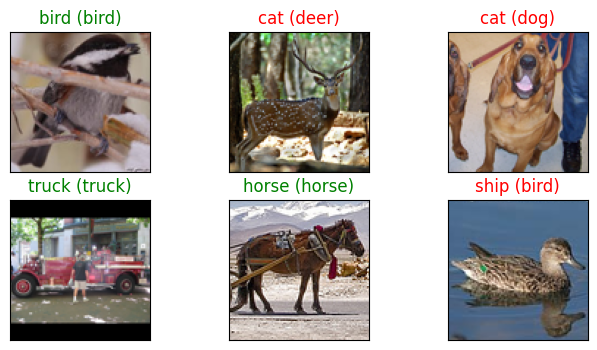

In [16]:
Test_plot(load_model, test_DL)